# Collab File to Train, Evaluate and Test the Gunshot Detection Model

In [ ]:
!wget https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz
!tar -xzf UrbanSound8K.tar.gz

--2026-03-15 15:29:51--  https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1203745/files/UrbanSound8K.tar.gz [following]
--2026-03-15 15:29:52--  https://zenodo.org/records/1203745/files/UrbanSound8K.tar.gz
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 6023741708 (5.6G) [application/octet-stream]
Saving to: ‘UrbanSound8K.tar.gz’

UrbanSound8K.tar.gz 100%[===================>]   5.61G  19.1MB/s    in 5m 3s   

2026-03-15 15:34:56 (18.9 MB/s) - ‘UrbanSound8K.tar.gz’ saved [6023741708/6023741708]



## Import required libraries

In [ ]:
# === Install Required Libraries ===
!pip install -q librosa tensorflow tensorflow_hub

import os
import numpy as np
import librosa
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive
from tqdm import tqdm
import joblib
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import pandas as pd

In [ ]:
# ========= Mount Google Drive =========
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Training and Evaluation

In [ ]:
# === Optional: Enable GPU memory growth ===
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# === Load VGGish ===
vggish_model = hub.load('https://tfhub.dev/google/vggish/1')

# === Extract VGGish Embeddings ===
def extract_vggish_embeddings(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        if len(audio) < int(sr * 0.96):
            raise ValueError("Audio too short for VGGish.")
        desired_len = sr * 10
        if len(audio) < desired_len:
            audio = np.pad(audio, (0, desired_len - len(audio)), mode='constant')
        else:
            audio = audio[:desired_len]
        audio_tensor = tf.convert_to_tensor(audio, dtype=tf.float32)
        embeddings = vggish_model(audio_tensor)
        return np.mean(embeddings.numpy(), axis=0)
    except Exception as e:
        raise RuntimeError(f"Failed to process {file_path}: {e}")

# === Load Dataset ===
data_dir = "/content/UrbanSound8K/audio"
metadata = pd.read_csv("/content/UrbanSound8K/metadata/UrbanSound8K.csv")

X = []
y = []

print("Extracting embeddings...")

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):

    file_name = row["slice_file_name"]
    fold = row["fold"]
    label = row["class"]

    file_path = os.path.join(data_dir, f"fold{fold}", file_name)

    try:
        emb = extract_vggish_embeddings(file_path)

        if not np.isnan(emb).any():
            X.append(emb)
            y.append(label)

    except Exception as e:
        print(e)

# === Encode Labels ===
X = np.array(X)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Save label encoder for future decoding
label_encoder_path = "/content/drive/MyDrive/Colab Notebooks/trained_models/label_encoder_510.pkl"
joblib.dump(le, label_encoder_path)

# === Split Data ===
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# === Classifier Model ===
model = Sequential([
    Dense(128, activation='relu', input_shape=(128,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(y_cat.shape[1], activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# === Callbacks ===
model_path = "/content/drive/MyDrive/Colab Notebooks/trained_models/laptop_vggish_trained_model_510data.keras"
checkpoint = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# === Train Model ===
history = model.fit(X_train, y_train, epochs=50, batch_size=16,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stop, checkpoint])

# === Evaluate Model ===
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

# === Plot Training ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()


## Model Analysis

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


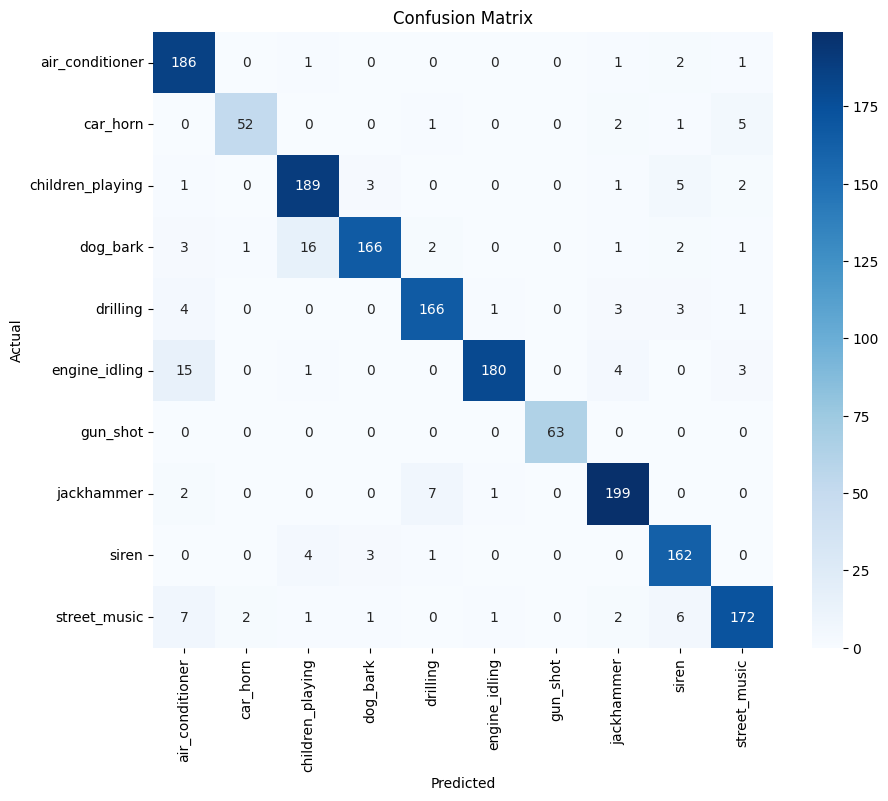

Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.85      0.97      0.91       191
        car_horn       0.95      0.85      0.90        61
children_playing       0.89      0.94      0.92       201
        dog_bark       0.96      0.86      0.91       192
        drilling       0.94      0.93      0.94       178
   engine_idling       0.98      0.89      0.93       203
        gun_shot       1.00      1.00      1.00        63
      jackhammer       0.93      0.95      0.94       209
           siren       0.90      0.95      0.92       170
    street_music       0.93      0.90      0.91       192

        accuracy                           0.92      1660
       macro avg       0.93      0.93      0.93      1660
    weighted avg       0.93      0.92      0.92      1660

Final Test Accuracy: 0.9247


In [ ]:
# === Predict and Decode ===
y_test_labels = np.argmax(y_test, axis=1)
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# === Confusion Matrix ===
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# === Classification Report ===
report = classification_report(y_test_labels, y_pred_labels, target_names=le.classes_)
print("Classification Report:\n", report)

# === Accuracy Score ===
test_acc = accuracy_score(y_test_labels, y_pred_labels)
print(f"Final Test Accuracy: {test_acc:.4f}")


## Model Testing

In [ ]:
label_encoder_path = "/content/drive/MyDrive/Colab Notebooks/trained_models/label_encoder_510.pkl"
model_path = "/content/drive/MyDrive/Colab Notebooks/trained_models/laptop_vggish_trained_model_510data.keras"

# === Load Required ===
from tensorflow.keras.models import load_model

# === Load Model and Label Encoder ===
model = tf.keras.models.load_model(model_path)
le = joblib.load(label_encoder_path)

# === Extract VGGish Embeddings ===
def extract_vggish_embeddings(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        if len(audio) < int(sr * 0.96):
            raise ValueError("Audio too short for VGGish.")
        desired_len = sr * 10
        if len(audio) < desired_len:
            audio = np.pad(audio, (0, desired_len - len(audio)), mode='constant')
        else:
            audio = audio[:desired_len]
        audio_tensor = tf.convert_to_tensor(audio, dtype=tf.float32)
        embeddings = vggish_model(audio_tensor)
        return np.mean(embeddings.numpy(), axis=0)
    except Exception as e:
        raise RuntimeError(f"Failed to process {file_path}: {e}")

# === Load VGGish ===
vggish_model = hub.load('https://tfhub.dev/google/vggish/1')

# === Prediction Function ===
def predict_audio_file(file_path):
    try:
        embedding = extract_vggish_embeddings(file_path)
        embedding = np.expand_dims(embedding, axis=0)  # shape: (1, 128)
        prediction = model.predict(embedding)
        predicted_index = np.argmax(prediction)
        predicted_label = le.inverse_transform([predicted_index])[0]
        print(f"Predicted Label: {predicted_label}")
        return predicted_label
    except Exception as e:
        print(f"Error: {e}")

# === Example Usage ===
predict_audio_file("/content/fast-gunshots-230519.mp3")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
Predicted Label: gun_shot


np.str_('gun_shot')

In [ ]:
# === OLD Code Gunshot Detection and Direction Estimation Pipeline ===

import sounddevice as sd
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import librosa.display
import tensorflow as tf
import tensorflow_hub as hub
import joblib
import os
import noisereduce as nr
from multiprocessing import Process, Manager
from tensorflow.keras.models import load_model

# === Constants ===
DURATION = 5  # seconds
FS = 44100
LOWCUT = 3000
HIGHCUT = 15000
GAIN_DB = 6
MIC_INDICES = [17,19,20]
MIC_LABELS = ["mic1", "mic2", "mic3"]
TEST_ANGLE = "test"

# === Model Paths ===
LABEL_ENCODER_PATH = "/content/drive/MyDrive/Colab Notebooks/trained_models/label_encoder_510.pkl"
MODEL_1_PATH = "/content/drive/MyDrive/Colab Notebooks/trained_models/laptop_vggish_trained_model_510data.keras"
MODEL_2_PATH = '/content/drive/MyDrive/Colab Notebooks/trained_models/gunshot_direction_model_v2.pkl'

# === Load ML Model 1 ===
model_1 = tf.keras.models.load_model(MODEL_1_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)
vggish_model = hub.load('https://tfhub.dev/google/vggish/1')

# === Load ML Model 2 ===
model_2, model_2_features = joblib.load(MODEL_2_PATH)

# === VGGish Embedding Extractor ===
def extract_vggish_embeddings(audio, sr=16000):
    if len(audio) < int(sr * 0.96):
        raise ValueError("Audio too short for VGGish.")
    desired_len = sr * 10
    if len(audio) < desired_len:
        audio = np.pad(audio, (0, desired_len - len(audio)), mode='constant')
    else:
        audio = audio[:desired_len]
    audio_tensor = tf.convert_to_tensor(audio, dtype=tf.float32)
    embeddings = vggish_model(audio_tensor)
    return np.mean(embeddings.numpy(), axis=0)

# === Predict Gunshot / Not ===
def predict_audio_array(audio, sr):
    audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    embedding = extract_vggish_embeddings(audio)
    embedding = np.expand_dims(embedding, axis=0)
    prediction = model_1.predict(embedding)
    predicted_index = np.argmax(prediction)
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    return predicted_label

# === Predict Direction ===
def predict_direction(m1, m2, m3):
    diff12 = m1 - m2
    diff13 = m1 - m3
    diff23 = m2 - m3
    total = m1 + m2 + m3
    norm1, norm2, norm3 = m1 / total, m2 / total, m3 / total
    peak_intensity = max(m1, m2, m3)
    features = np.array([[m1, m2, m3, diff12, diff13, diff23, norm1, norm2, norm3, peak_intensity]])
    return model_2.predict(features)[0]

# === Process Each Mic Audio ===
# === Process Each Mic Audio ===
def process_audio(audio, fs, label, results_dict, test_number):
    # Save raw audio
    raw_audio = audio.copy()

    # Bandpass Filter
    order = 4
    nyq = 0.5 * fs
    low = LOWCUT / nyq
    high = HIGHCUT / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    filtered_audio = signal.filtfilt(b, a, audio)

    # Noise Reduction
    denoised_audio = nr.reduce_noise(y=filtered_audio, sr=fs)

    # Save raw and filtered audios
    sf.write(f"{TEST_ANGLE}_{test_number}_{label}_raw.wav", raw_audio, fs)
    sf.write(f"{TEST_ANGLE}_{test_number}_{label}_filtered.wav", denoised_audio, fs)

    # Find peak from filtered audio
    t = np.linspace(0, len(audio)/fs, len(audio))
    pos_idx = np.where(denoised_audio > 0)[0]
    if len(pos_idx) > 0:
        max_index = np.argmax(denoised_audio[pos_idx])
        peak_val = denoised_audio[pos_idx[max_index]]
        peak_time = t[pos_idx[max_index]]
        print(f"🔍 {label.upper()} Peak: {peak_val:.4f} at {peak_time:.4f}s")
    else:
        peak_val = 0
        print(f"⚠️ {label.upper()} No positive peak detected.")
        peak_time = None

    # Save both audios and peak to results dict
    results_dict[label] = {
        "raw_audio": raw_audio,          # For gunshot classification
        "filtered_audio": denoised_audio, # For peak detection
        "sr": fs,
        "peak": peak_val
    }

# === Record Audio from Mic ===
def record_mic(index, label, results_dict, test_number):
    print(f"🎙️ Recording {label}...")
    audio = sd.rec(int(DURATION * FS), samplerate=FS, channels=1, dtype='float32', device=index)
    sd.wait()
    audio = audio.flatten()
    process_audio(audio, FS, label, results_dict, test_number)

#=== Plot Radar ===
def plot_gunshot_direction(angle):

    if(angle == 0 or angle == 360):
        start_angle = -30
        end_angle = 30
    elif(angle == 60):
        start_angle = 270
        end_angle = 330
    elif(angle == 120):
        start_angle = 210
        end_angle = 270
    elif(angle == 180):
        start_angle = 150
        end_angle = 210
    elif(angle == 240):
        start_angle = 90
        end_angle = 150
    elif(angle == 300):
        start_angle = 30
        end_angle = 90

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
    fig.patch.set_facecolor('black')  # Background of figure

    # Radar settings
    ax.set_facecolor('darkgreen')    # Radar (circle) background
    ax.set_theta_zero_location('N')  # 0 degrees at the top
    ax.set_theta_direction(-1)       # Clockwise
    ax.set_rticks([])                # Remove radial ticks
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 60)))  # Add gridlines at every 45°
    ax.grid(color='lightgreen', linestyle='--', linewidth=0.7)

    # Plot detected sector
    theta = np.linspace(np.deg2rad(start_angle), np.deg2rad(end_angle), 100)
    r = np.ones_like(theta)
    ax.fill_between(theta, 0, r, color='lime', alpha=0.6)  # Highlighted detected region

    # Circle border
    circle = plt.Circle((0, 0), 1, transform=ax.transData._b, color='lightgreen', fill=False, linewidth=2)
    ax.add_artist(circle)
    plt.show()

# === Main Pipeline ===
def main():
    test_number = input("Enter test number: ")

    print("🎬 Starting 3-mic recording session...")
    with Manager() as manager:
        results = manager.dict()
        processes = []

        for idx, label in zip(MIC_INDICES, MIC_LABELS):
            p = Process(target=record_mic, args=(idx, label, results, test_number))
            p.start()
            processes.append(p)
        for p in processes:
            p.join()

        # Extract peak values and audios
        mic_peaks = {label: results[label]["peak"] for label in MIC_LABELS}
        mic_raw_audio = {label: results[label]["raw_audio"] for label in MIC_LABELS}
        mic_sr = results[MIC_LABELS[0]]["sr"]

        # Find mic with max peak
        max_mic_label = max(mic_peaks, key=mic_peaks.get)
        selected_raw_audio = mic_raw_audio[max_mic_label]

        print(f"\n📌 Highest peak from: {max_mic_label.upper()}")

        # Predict gunshot using raw audio
        predicted_label = predict_audio_array(selected_raw_audio, mic_sr)

        if predicted_label.lower() == "gunshot":
            print("✅ Gunshot Detected!")
            # Predict direction using filtered peaks
            direction = predict_direction(mic_peaks["mic1"], mic_peaks["mic2"], mic_peaks["mic3"])
            print(f"🎯 Predicted Direction: {direction}°")
            plot_gunshot_direction(direction)
        else:
            print("❌ Not a gunshot.")

if __name__ == "__main__":
    main()

: 